In [13]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
from scipy.optimize import curve_fit 

(100, 6)
There are 100 rows and 6 columns
          x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
0 -1.000000  11.624419   8.296963  12.201067   7.811725   3.155566
1 -0.929293  10.377466   9.674440  12.198084   8.275006   7.518855
2 -0.858586  10.585100   9.251983  13.186565  12.926586   9.963630
3 -0.787879  10.913928   7.786344  12.552304  11.832379   9.625801
4 -0.717172   8.640287   8.551869   4.741432   8.790834   6.624113
           x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
95  5.717172  -1.411918   0.822231  -2.027132  -1.825106   2.746147
96  5.787879   0.344879  -1.718956   2.747559  -6.803779  -5.137472
97  5.858586   0.307133   0.353528   0.967976   5.461567  -0.905616
98  5.929293   0.048657   0.159961   2.482130  -0.414616  -4.334548
99  6.000000  -0.193438  -2.244792   1.930035   4.992414  -6.872850
The column names are Index(['x', 'y_noise_1', 'y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5'], dtype='object')


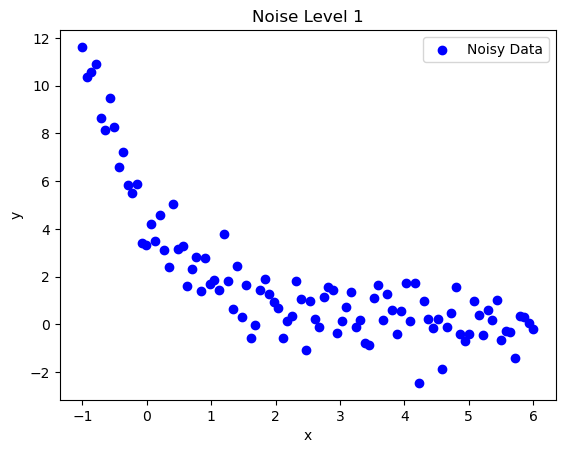

Fit:y=4.71 * e^(-0.92*x)
Reduced Chi Square: 0.79


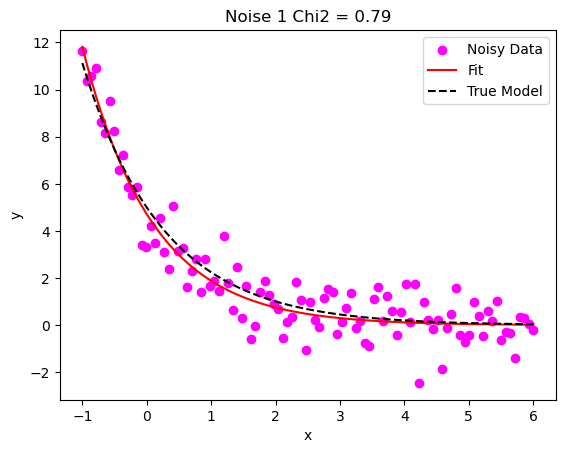

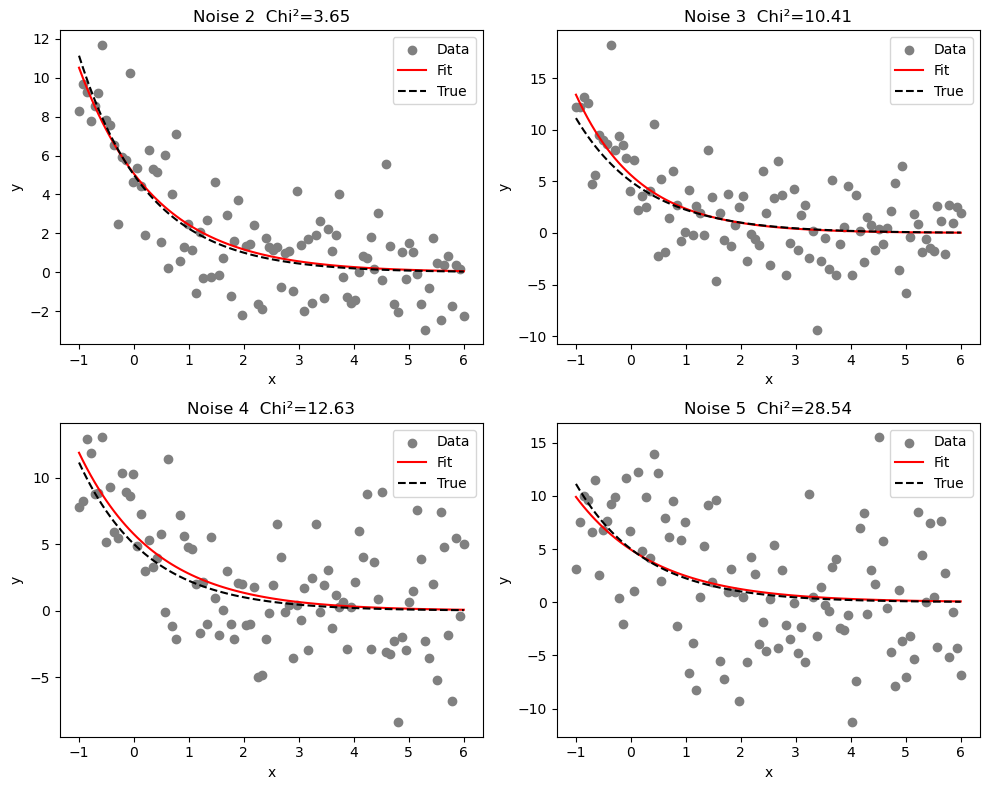

In [15]:
data = pd.read_csv('noisy_curvefit_data.csv')
print (data.shape)
print(f'There are {data.shape[0]} rows and {data.shape[1]} columns')
print(data.head()) 
print(data.tail())
print(f'The column names are {data.columns}')

x = data['x']
y_noise_1 = data['y_noise_1']
plt.scatter(x, y_noise_1, color = 'blue', label = 'Noisy Data')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Noise Level 1')
plt.legend()
plt.show()

def model(x, A, k):
    return A * np.exp(-k*x)
popt, pcov = curve_fit(model, x, y_noise_1, p0 = [1,1])
A_fit, k_fit = popt
print(F'Fit:y={A_fit:.2f} * e^(-{k_fit:.2f}*x)')
residuals = y_noise_1 - model(x, A_fit, k_fit)
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
chi2_reduced = chi2 / dof
print(f'Reduced Chi Square: {chi2_reduced:.2f}')

plt.scatter(x, y_noise_1, color="magenta", label="Noisy Data")
plt.plot(x, model(x, A_fit, k_fit), 'r-', label = 'Fit')
plt.plot(x, model(x,5,0.8), 'k--', label = "True Model")
plt.title(f'Noise 1 Chi2 = {chi2_reduced:.2f}')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

def fit_model(x,y):
    popt, _ = curve_fit(model, x, y, p0 = [1,1])
    A_fit, k_fit = popt

    residuals = y - model(x, A_fit, k_fit)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_reduced = chi2/dof 

    return A_fit, k_fit, chi2_reduced 

fig, axes = plt.subplots(2,2,figsize = (10,8))

noise_levels = ['y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5']
results = []
for i, col in enumerate(noise_levels):
    ax = axes[i//2, i%2]
    y = df[col]
    A_fit, k_fit, chi2_reduced = fit_model(x, y)
    results.append([i+2, A_fit, k_fit, chi2_reduced])
    ax.scatter(x, y, color="gray", label="Data")
    ax.plot(x, model(x, A_fit, k_fit), 'r-', label="Fit")
    ax.plot(x, model(x, 5, 0.8), 'k--', label="True")
    ax.set_title(f"Noise {i+2}  Chi²={chi2_reduced:.2f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()
plt.tight_layout()
plt.show()

#as noise increases red line deviates more from black line and data is scattered
#chi2 increases as residuals get larger making it a worser fit 

results.insert(0, [1,A_fit,k_fit,chi2_reduced])
dataresults = pd.DataFrame(results, columns =['Noise Level', 'A_fit', 'k_fit', 'Reduced Chi2', ])
dataresults.to_csv('noisy_parameters.csv', index = False)

